# Activity: Address missing data 

## Introduction

The datasets that data professionals use to solve problems typically contain missing values, which must be dealt with in order to achieve clean, useful data. This is particularly crucial in exploratory data analysis (EDA). In this activity, you will learn how to address missing data. 

You are a financial data consultant, and an investor has tasked your team with identifying new business opportunities. To help them decide which future companies to invest in, you will provide a list of current businesses valued at more than $1 billion. These are sometimes referred to as "unicorns." Your client will use this information to learn about profitable businesses in general.

The investor has asked you to provide them with the following data: 
- Companies in the `hardware` industry based in either `Beijing`, `San Francisco`, or `London` 
- Companies in the `artificial intelligence` industry based in `London`
-  A list of the top 20 countries sorted by sum of company valuations in each country, excluding `United States`, `China`, `India`, and `United Kingdom`
- A global valuation map of all countries with companies that joined the list after 2020
- A global valuation map of all countries except `United States`, `China`, `India`, and `United Kingdom` (a separate map for Europe is also required)

Your dataset includes a list of businesses and data points, such as the year they were founded; their industry; and their city, country, and continent. 

## **Step 1: Imports** 

### Import libraries

Import the following relevant Python libraries:
* `numpy`
* `pandas`
* `matplotlib.pyplot`
* `plotly.express`
* `seaborn`



In [1]:
# Import libraries and modules.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset


The dataset is currently in CSV format and in a file named `Unicorn_Companies.csv`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

df_companies = pd.read_csv("Unicorn_Companies.csv")

## **Step 2: Data exploration** 

Explore the dataset and answer questions that will guide your management of missing values. 

### Display top rows

Display the first 10 rows of the data to understand how the dataset is structured.

In [3]:
# Display the first 10 rows of the data.

df_companies.head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,1/8/18,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,5/2/19,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,12/30/14,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,12/20/17,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2/5/19,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


### Statistical properties of the dataset

Use methods and attributes of the dataframe to get information and descriptive statistics for the data, including its range, data types, mean values, and shape. 


In [4]:
# Get the shape of the dataset.

df_companies.shape

(1074, 10)

**Question: What is the shape of the dataset?**

The Dataset has 1074 rows and 10 columns

In [5]:
# Get the data types and number of non-null values in the dataset.

df_companies.info()

<class 'pandas.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Company           1074 non-null   str  
 1   Valuation         1074 non-null   str  
 2   Date Joined       1074 non-null   str  
 3   Industry          1074 non-null   str  
 4   City              1058 non-null   str  
 5   Country/Region    1074 non-null   str  
 6   Continent         1074 non-null   str  
 7   Year Founded      1074 non-null   int64
 8   Funding           1074 non-null   str  
 9   Select Investors  1073 non-null   str  
dtypes: int64(1), str(9)
memory usage: 84.0 KB


**Question: What are the data types of various columns?**


There are 9 columns with str data types, and one (Year Founded) is int64

**Question: How many columns contain null values?**

Two columns contain null values, Select Investors and City

In [6]:
# Get descriptive statistics such as mean, standard deviation, and range of the numerical columns in the dataset.

df_companies.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


**Question: In what year was the oldest company founded?**

The oldest company was founded in 1919 

### Data Preprocessing

In order to answer the investor's questions, some data preprocessing steps are required. The first step is to add a new column to the dataframe containing just the year each company became a unicorn company. Call this new column `Year Joined`. 

In [7]:
# Create a new column "Year Joined" from "Date Joined".

df_companies['Year Joined'] = pd.to_datetime(df_companies['Date Joined']).dt.year

C:\Users\yeiso\AppData\Local\Temp\ipykernel_18028\3087912708.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_companies['Year Joined'] = pd.to_datetime(df_companies['Date Joined']).dt.year


For each country, you want to calculate the sum of all valuations of companies from that country. However, in order to do this, you'll need to first prepare the data. Currently, the data in the `Valuation` column is a string that starts with a `$` and ends with a `B`. Because this column is not in a numeric datatype, pandas cannot perform mathematical operations on its values. The data in this column needs to be converted to a numeric datatype. 

In this step, define a function called `str_to_num()` that accepts as an argument:

* `x`: a string in the format of the values contained in the `Valuation` column

And returns:

* `x`: an `int` of the number represented by the input string

```
Example:

 [IN]:  str_to_num('$4B')
[OUT]:  4

```


To do this, use the string [`strip()`](https://docs.python.org/3/library/stdtypes.html#str.strip) method. This method is applied to a string. Its argument is a string that contains all the characters that you want to remove from the beginning and end of a given string&mdash;in any order. The specified characters will be removed until a valid character is encountered. This process is applied moving forward from the beginning of the string and also moving in reverse from the end of the string, thus removing unwanted beginning and trailing characters.

```
Example:

 [IN]:  my_string = '#....... Section 3.2.1 Issue #32 .......'
        my_string = my_string.strip('.#! ')
        print(my_string)

[OUT]:  'Section 3.2.1 Issue #32'

```

Note that you must reassign the result back to a variable or else the change will not be permanent. 

In [ ]:
# Define the `str_to_num()` function

def str_to_num(x): 
    x = x.strip('$B')
    return int(x)


4
12
<class 'int'>


Now, use this function to create a new column called `valuation_num` that represents the `Valuation` column as an integer value. To do this, use the series method [`apply()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) to apply the `str_to_num()` function to the `Valuation` column.

`apply()` is a method that can be used on a `DataFrame` or `Series` object. In this case, you're using it on the `Valuation` series. The method accepts a function as an argument and applies that function to each value in the series.

```
Example:

 [IN]: def square(x):
           return x ** 2

       my_series = pd.Series([0, 1, 2, 3])
       my_series

[OUT]: 0    0
       1    1
       2    2
       3    3
       dtype: int64

 [IN]: my_series = my_series.apply(square)
       my_series

[OUT]: 0    0
       1    1
       2    4
       3    9
       dtype: int64
```

Notice that the function passed as an argument to the `apply()` method does not have parentheses. It's just the function name.

In [12]:
# Apply the `str_to_num()` function to the `Valuation` column
# and assign the result back to a new column called `valuation_num`

df_companies['valuation_num'] = df_companies['Valuation'].apply(str_to_num)

### Find missing values

The unicorn companies dataset is fairly clean, with few missing values. 

In [13]:
# Find the number of missing values in each column in this dataset.

df_companies.isnull().sum()

Company              0
Valuation            0
Date Joined          0
Industry             0
City                16
Country/Region       0
Continent            0
Year Founded         0
Funding              0
Select Investors     1
Year Joined          0
valuation_num        0
dtype: int64

 **Question: How many missing values are in each column in the dataset?**

The column Select Investors has 1 missing value, the column City has 16, the others has not missing values.

### Review rows with missing values

Before dealing with missing values, it's important to understand the nature of the missing value that is being filled. Display all rows with missing values from `df_companies`. To do this, perform the following three steps:

1. Apply the `isna()` method to the `df_companies` dataframe as you did in the last step. Remember, this results in a dataframe of the same shape as `df_companies` where each value is `True` if its contents are `NaN` and a `False` if its contents are not `NaN`. Assign the results to a variable called `mask`.

In [23]:
# 1. Apply the `isna()` method to the `df_companies` dataframe and assign back to `mask`

mask = df_companies.isna()

You're not done yet. You still need to go from this dataframe of Boolean values to a dataframe of just the rows of `df_companies` that contain at least one `NaN` value. This means that you need a way to find the indices of the rows of the Boolean dataframe that contain at least one `True` value, then extract those indices from `df_companies`. 

You can do this using the [`any()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html) method for `DataFrame` objects. This method returns a Boolean `Series` indicating whether any value is `True` over a specified axis.

```
Example:

df =     
        A      B    C
    0   0      a    10
    1   False  0    1
    2   NaN    NaN  NaN


 [IN]: df.any(axis=0)

[OUT]: A    False
       B     True
       C     True
       dtype: bool
       
 [IN]: df.any(axis=1)
 
[OUT]: 0     True
       1     True
       2    False
       dtype: bool
```

Note that `0`, `False`, and `NaN` are considered `False` and anything else is considered `True`. 

2. Apply the `any()` method to the Boolean dataframe you created to make a Boolean series where each element in the series represents `True` if a row of the dataframe contains any `True` values and `False` if any row in the dataframe contains any `False` values. Assign the results back to `mask`.

In [24]:
# 2. Apply the `any()` method to `mask` and assign the results back to `mask`

mask = mask.any(axis=1)


3. Because `mask` is now a series of Boolean values, you can use it as a Boolean mask. Apply the Boolean mask to the `df_companies` dataframe to return a filtered dataframe containing just the rows that contain a missing value. Assign the results to a variable called `df_missing_rows`.

In [28]:
# 3. Apply `mask` as a Boolean mask to `df_companies` and assign results to `df_missing_rows`

df_missing_rows = df_companies[mask]
df_missing_rows

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
12,FTX,$32B,7/20/21,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,32
170,HyalRoute,$4B,5/26/20,Mobile & telecommunications,NaN,Singapore,Asia,2015,$263M,Kuang-Chi,2020,4
242,Moglix,$3B,5/17/21,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2015,$471M,"Jungle Ventures, Accel, Venture Highway",2021,3
251,Trax,$3B,7/22/19,Artificial intelligence,NaN,Singapore,Asia,2010,$1B,"Hopu Investment Management, Boyu Capital, DC T...",2019,3
325,Amber Group,$3B,6/21/21,Fintech,NaN,Hong Kong,Asia,2015,$328M,"Tiger Global Management, Tiger Brokers, DCM Ve...",2021,3
382,Ninja Van,$2B,9/27/21,"Supply chain, logistics, & delivery",NaN,Singapore,Asia,2014,$975M,"B Capital Group, Monk's Hill Ventures, Dynamic...",2021,2
541,Advance Intelligence Group,$2B,9/23/21,Artificial intelligence,NaN,Singapore,Asia,2016,$536M,"Vision Plus Capital, GSR Ventures, ZhenFund",2021,2
629,LinkSure Network,$1B,1/1/15,Mobile & telecommunications,Shanghai,China,Asia,2013,$52M,NaN,2015,1
811,Carousell,$1B,9/15/21,E-commerce & direct-to-consumer,NaN,Singapore,Asia,2012,$288M,"500 Global, Rakuten Ventures, Golden Gate Vent...",2021,1
848,Matrixport,$1B,6/1/21,Fintech,NaN,Singapore,Asia,2019,$100M,"Dragonfly Captial, Qiming Venture Partners, DS...",2021,1


**Question: Is there a specific country/region that shows up a lot in this missing values dataframe? Which one?**


The continent of Asia, the Countries of Singapore, China, Hong Kong.

**Question: What steps did you take to find missing data?**


To identify missing data, I first used `df.isnull().sum()` to count the number of missing values in each column. Then, I created a Boolean mask with `mask = df.isna().any(axis=1)` to identify rows containing at least one missing value. Finally, I applied the mask to the DataFrame (`df[mask]`) to display and inspect all rows with missing data, allowing me to determine where the missing values were located.


**Question: What observations can be made about the forms and context of missing data?**


The missing data are concentrated mainly in the `City` column for companies located in Asia, particularly in China, Singapore, and Hong Kong. There is also one isolated missing city value for a company in the Bahamas. Additionally, there is a single missing value in the `Select Investors` column for a company from the same region. Overall, the missing data are limited and appear to be concentrated in a few specific locations rather than being widespread across the dataset.

**Question: What other methods could you use to address missing data?**


Other methods to address missing data include removing rows or columns with missing values when appropriate, imputing missing values using the mean, median, or mode, replacing missing categorical values with a label such as "Unknown," or obtaining the missing information from reliable external sources. The most suitable method depends on the amount of missing data and its importance to the analysis.

## Step 3: Model building

Think of the model you are building as the completed dataset, which you will then use to inform the questions the investor has asked of you.  

### Two ways to address missing values

There are several ways to address missing values, which is critical in EDA. The two primary methods are removing them and imputing other values in their place. Choosing the proper method depends on the business problem and the value the solution will add or take away from the dataset.

Here, you will try both. 

To compare the the effect of different actions, first store the original number of values in a variable. Create a variable called `count_total` that is an integer representing the total number of values in `df_companies`. For example, if the dataframe had 5 rows and 2 columns, then this number would be 10.

In [36]:
# Store the total number of values in a variable called `count_total`
count_total = df_companies.size
count_total

12888

Now, remove all rows containing missing values and store the total number of remaining values in a variable called `count_dropna_rows`.

In [38]:
# Drop the rows containing missing values, determine number of remaining values 

count_dropna_rows = df_companies.dropna().size
count_dropna_rows

12684

Now, remove all columns containing missing values and store the total number of cells in a variable called `count_dropna_columns`.

In [39]:
# Drop the columns containing missing values, determine number of remaining values

count_dropna_cols = df_companies.dropna(axis=1).size
count_dropna_cols

10740

Next, print the percentage of values removed by each method and compare them.

In [42]:
# Print the percentage of values removed by dropping rows.

count_dropna_rows_percentage = (count_total - count_dropna_rows) / count_total * 100
print(f"Percentage of values removed by dropping rows: {count_dropna_rows_percentage:.2f}%")

# Print the percentage of values removed by dropping columns.
count_dropna_cols_percentage = (count_total - count_dropna_cols) / count_total * 100
print(f"Percentage of values removed by dropping columns: {count_dropna_cols_percentage:.2f}%")


Percentage of values removed by dropping rows: 1.58%
Percentage of values removed by dropping columns: 16.67%


**Question: Which method was most effective? Why?**


Dropping rows was the most effective method because it removed only 1.58% of the data, while dropping columns removed 16.67%. Since the missing values represented a small portion of the dataset, removing the affected rows preserved much more information and minimized data loss.

Now, practice the second method: imputation. Perform the following steps:

1. Use the [`fillna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html#pandas.DataFrame.fillna) dataframe method to fill each missing value with the next non-NaN value in its column. Assign the results to a new dataframe called `df_companies_backfill`.

```
Example:

df =     
        A    B    C
    0   5    a    NaN
    1   10   NaN  False
    2   NaN  c    True

 [IN]: df.fillna(method='backfill')
 
[OUT]: 
        A    B    C
    0   5    a    False
    1   10   c    False
    2   NaN  c    True

```

Notice that if there is a `NaN` value in the last row, it will not backfill because there is no subsequent value in the column to refer to. 

2. Show the rows that previously had missing values.

In [ ]:
# 1. Fill missing values using the 'fillna()' method, back-filling
df_companies_backfilled = df_companies.bfill()


# 2. Show the rows that previously had missing values
df_companies_backfilled.iloc[df_missing_rows.index]


,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,valuation_num
12,FTX,$32B,7/20/21,Fintech,Jacksonville,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,32
170,HyalRoute,$4B,5/26/20,Mobile & telecommunications,El Segundo,Singapore,Asia,2015,$263M,Kuang-Chi,2020,4
242,Moglix,$3B,5/17/21,E-commerce & direct-to-consumer,San Francisco,Singapore,Asia,2015,$471M,"Jungle Ventures, Accel, Venture Highway",2021,3
251,Trax,$3B,7/22/19,Artificial intelligence,Amsterdam,Singapore,Asia,2010,$1B,"Hopu Investment Management, Boyu Capital, DC T...",2019,3
325,Amber Group,$3B,6/21/21,Fintech,San Francisco,Hong Kong,Asia,2015,$328M,"Tiger Global Management, Tiger Brokers, DCM Ve...",2021,3
382,Ninja Van,$2B,9/27/21,"Supply chain, logistics, & delivery",San Francisco,Singapore,Asia,2014,$975M,"B Capital Group, Monk's Hill Ventures, Dynamic...",2021,2
541,Advance Intelligence Group,$2B,9/23/21,Artificial intelligence,Helsinki,Singapore,Asia,2016,$536M,"Vision Plus Capital, GSR Ventures, ZhenFund",2021,2
629,LinkSure Network,$1B,1/1/15,Mobile & telecommunications,Shanghai,China,Asia,2013,$52M,"Sequoia Capital India, The Times Group, GMO Ve...",2015,1
811,Carousell,$1B,9/15/21,E-commerce & direct-to-consumer,New York,Singapore,Asia,2012,$288M,"500 Global, Rakuten Ventures, Golden Gate Vent...",2021,1
848,Matrixport,$1B,6/1/21,Fintech,San Francisco,Singapore,Asia,2019,$100M,"Dragonfly Captial, Qiming Venture Partners, DS...",2021,1


**Question: Do the values that were used to fill in for the missing values make sense?**


No, the imputed values do not make sense. The backfill method replaced missing city values for companies in Asia with cities such as San Francisco, New York, and Helsinki from subsequent rows. These locations do not correspond to the companies' actual countries or regions, making the imputed values inaccurate. In this case, backfilling is not an appropriate method for the `City` column.

Another option is to fill the values with a certain value, such as 'Unknown'. However, doing so doesn’t add any value to the dataset and could make finding the missing values difficult in the future. Reviewing the missing values in this dataset determines that it is fine to leave the values as they are. This also avoids adding bias to the dataset.

## Step 4: Results and evaluation

Now that you've addressed your missing values, provide your investor with their requested data points.

### Companies in the `Hardware` Industry

Your investor is interested in identifying unicorn companies in the `Hardware` industry in the following cities: `Beijing`, `San Francisco`, and `London`. They are also interested in companies in the `Artificial intelligence` industry in `London`. 

Write a selection statement that extracts the rows that meet these criteria. This task requires complex conditional logic. Break the process into the following parts.

1. Create a mask to apply to the `df_companies` dataframe. The following logic is a pseudo-code representation of how this mask could be structured.

```
((Industry==Hardware) and (City==Beijing, San Francisco, or London)) 
OR  
((Industry==Artificial intelligence) and (City==London))
```

You're familiar with how to create Boolean masks based on conditional logic in pandas. However, you might not know how to write a conditional statement that selects rows that have _any one of several possible values_ in a given column. In this case, this is the `(City==Beijing, San Francisco, or London)` part of the expression.

For this type of construction, use the [`isin()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.isin.html#pandas.Series.isin) `Series` method. This method is applied to a pandas series and, for each value in the series, checks whether it is a member of whatever is passed as its argument.

```
Example:

 [IN]: my_series = pd.Series([0, 1, 2, 3])
       my_series
       
[OUT]: 0    0
       1    1
       2    2
       3    3
       dtype: int64
       
 [IN]: my_series.isin([1, 2])
       
[OUT]: 0    False
       1     True
       2     True
       3    False
       dtype: bool
       
```

2. Apply the mask to the `df_companies` dataframe and assign the result to a new variable called `df_invest`.

In [49]:
# 1. Create a Boolean mask using conditional logic

cities = ["Beijing", "San Francisco", "London"]
mask = (
    (df_companies['Industry']== 'Hardware') & (df_companies['City'].isin(cities)) 
        | (df_companies['Industry']== 'Artificial Intelligence') & (df_companies['City'] == "London") 
        )

# 2. Apply the mask to the `df_companies` dataframe and assign the results to `df_invest`

df_invest = df_companies[mask]
df_invest.size

72

**Question: How many companies meet the criteria given by the investor?**


The criteria is meet for 72 companies

### List of countries by sum of valuation

For each country, sum the valuations of all companies in that country, then sort the results in descending order by summed valuation. Assign the results to a variable called `national_valuations`.

In [50]:
# Group the data by`Country/Region`

national_valuations = df_companies.groupby('Country/Region')['valuation_num'].sum().sort_values(ascending=False)

# Print the top 15 values of the DataFrame.

national_valuations.head(15)

Country/Region
United States     1933
China              696
India              196
United Kingdom     195
Germany             72
Sweden              63
Australia           56
France              55
Canada              49
South Korea         41
Israel              39
Brazil              37
Bahamas             32
Indonesia           28
Singapore           21
Name: valuation_num, dtype: int64

**Question: Which countries have the highest sum of valuation?**

The highest sum of valuation is for United States

### Filter out top 4 outlying countries

Use this grouped and summed data to plot a barplot. However, to meet the needs of your stakeholder, you must first remove the United States, China, India, and the United Kingdom. Remove these countries from `national_valuations` and reassign the results to a variable called `national_valuations_no_big4`.

In [51]:
# Remove outlying countries

national_valuations_no_big4 = national_valuations.iloc[4:]
national_valuations_no_big4

Country/Region
Germany                 72
Sweden                  63
Australia               56
France                  55
Canada                  49
South Korea             41
Israel                  39
Brazil                  37
Bahamas                 32
Indonesia               28
Singapore               21
Netherlands             19
Hong Kong               18
Turkey                  16
Mexico                  16
Estonia                 13
Finland                 12
Ireland                  9
Belgium                  8
Japan                    8
Switzerland              8
Austria                  7
Denmark                  7
Colombia                 6
Vietnam                  5
Lithuania                5
Norway                   5
United Arab Emirates     5
Spain                    4
South Africa             3
Chile                    3
Thailand                 3
Philippines              3
Bermuda                  2
Nigeria                  2
Luxembourg               2
Argentina    

### BONUS CONTENT: Alternative approach (optional)

You can also use `isin()` to create a Boolean mask to filter out specific values of the `Country/Region` column. In this case, this process is longer and more complicated than simply using the iloc[] statement. However, there will be situations where this is the most direct approach. 
    
How could you use `isin()` and your knowledge of pandas conditional operators and Boolean masks to accomplish the same task?


In [55]:
# (Optional) Use `isin()` to create a Boolean mask to accomplish the same task

mask = ~national_valuations.index.isin(
    ["United States", "China", "India", "United Kingdom"]
)

national_valuations_no_big4 = national_valuations[mask]
national_valuations_no_big4

Country/Region
Germany                 72
Sweden                  63
Australia               56
France                  55
Canada                  49
South Korea             41
Israel                  39
Brazil                  37
Bahamas                 32
Indonesia               28
Singapore               21
Netherlands             19
Hong Kong               18
Turkey                  16
Mexico                  16
Estonia                 13
Finland                 12
Ireland                  9
Belgium                  8
Japan                    8
Switzerland              8
Austria                  7
Denmark                  7
Colombia                 6
Vietnam                  5
Lithuania                5
Norway                   5
United Arab Emirates     5
Spain                    4
South Africa             3
Chile                    3
Thailand                 3
Philippines              3
Bermuda                  2
Nigeria                  2
Luxembourg               2
Argentina    

### Create barplot for top 20 non-big-4 countries

Now, the data is ready to reveal the top 20 non-big-4 countries with the highest total company valuations. Use seaborn's [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function to create a plot showing national valuation on one axis and country on the other.

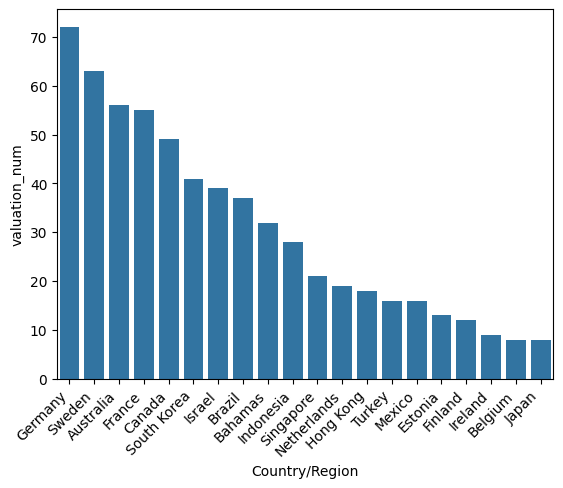

In [60]:
# Create a barplot to compare the top 20 countries with highest company valuations.

top20 = national_valuations_no_big4.head(20).reset_index()

sns.barplot(data=top20, x='Country/Region', y='valuation_num')
plt.xticks(rotation=45, ha='right')

# Show the plot.
plt.show()

### Plot maps

Your investor has also asked for a global valuation map of all countries except `United States`, `China`, `India`, and `United Kingdom` (a.k.a. "big-four countries").

You have learned about using [`scatter_geo()`](https://plotly.com/python-api-reference/generated/plotly.express.scatter_geo) from the `plotly.express` library to create plot data on a map. Create a `scatter_geo()` plot that depicts the total valuations of each non-big-four country on a world map, where each valuation is shown as a circle on the map, and the size of the circle is proportional to that country's summed valuation.

In [62]:
# Plot the sum of valuations per country.
import plotly.express as px 

national_valuations_no_big4 = national_valuations_no_big4.reset_index()

fig = px.scatter_geo(
    national_valuations_no_big4, 
    locations='Country/Region', 
    locationmode='country names', 
    color='Country/Region',
    size='valuation_num',
    title="Total Valuation by Country (Excluding Big Four Countries)"
    )

fig.show()


C:\Users\yeiso\AppData\Local\Temp\ipykernel_18028\2634533743.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


**Question: How is the valuation sum per country visualized in the plot?**


The total valuation sum per country is visualized using bubbles (or circles) overlaid on a world map, where the size of each bubble corresponds to the magnitude of the valuation sum (larger bubbles represent a higher total valuation)

**Question: Does any region stand out as having a lot of activity?**


Yes, Europe stands out with a dense concentration of overlapping bubbles, indicating high activity across multiple countries. Additionally, regions like East/Southeast Asia and parts of the Americas also show noticeable clusters of activity.

## Conclusion

**What are some key takeaways that you learned during this lab?**

During this lab, I learned how to explore and analyze a dataset using Python, pandas, and data visualization libraries. I practiced cleaning and transforming data, grouping information to identify trends, and creating visualizations to better understand patterns in unicorn companies. I learned that visualizations such as bar charts, scatter plots, and geographic maps can make complex data easier to interpret and help identify important insights, such as countries with the highest total valuations and changes in unicorn growth over time.

**How would you present your findings from this lab to others? Consider the information you would provide (and what you would omit), how you would share the various data insights, and how data visualizations could help your presentation.**

I would present the findings using clear visualizations and focus on the most relevant insights, such as valuation distribution, top countries by total valuation, and trends in the creation of unicorn companies over time. I would avoid including unnecessary details or raw data that could distract from the main conclusions. Charts and maps would help communicate patterns more effectively and allow stakeholders to quickly understand the main factors influencing the unicorn market. I would combine the visualizations with brief explanations of the key findings and their potential business implications.




**Reference**

[Bhat, M.A. *Unicorn Companies*](https://www.kaggle.com/datasets/mysarahmadbhat/unicorn-companies)

